In [36]:
!pip install seaborn scikit-image


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# DatasetLoader

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATASET_DIR = "dataset" 
IMG_SIZE = 128
CHANNELS = 1
SEED = 42
np.random.seed(SEED)

In [2]:
def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for img_name in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label)

        except Exception as e:
            print(f"Skipping {img_name}: {e}")

    return images, labels

In [3]:
tumor_path = os.path.join(DATASET_DIR, "tumor")
no_tumor_path = os.path.join(DATASET_DIR, "no_tumor")

tumor_imgs, tumor_labels = load_images_from_folder(tumor_path, label=1)
no_tumor_imgs, no_tumor_labels = load_images_from_folder(no_tumor_path, label=0)

X = np.array(tumor_imgs + no_tumor_imgs)
y = np.array(tumor_labels + no_tumor_labels)

print("Total images:", X.shape[0])
print("Tumor images:", len(tumor_imgs))
print("No-tumor images:", len(no_tumor_imgs))

Total images: 5446
Tumor images: 2337
No-tumor images: 3109


In [4]:
# Normalize to [-1, 1] (GAN standard)
X = (X.astype("float32") - 127.5) / 127.5

# Add channel dimension
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, CHANNELS)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

#Normalization range = [-1, 1]
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Final X shape: (5446, 128, 128, 1)
Final y shape: (5446,)
Min pixel value: -1.0
Max pixel value: 1.0


In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create deterministic split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)

for train_idx, val_idx in sss.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

# Save indices permanently
np.save("train_idx.npy", train_idx)
np.save("val_idx.npy", val_idx)

print("✅ Dataset split saved.")
print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

✅ Dataset split saved.
Train samples: 4629
Validation samples: 817


In [5]:
train_idx = np.load("train_idx.npy")
val_idx = np.load("val_idx.npy")

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print("✅ Loaded saved dataset split.")

✅ Loaded saved dataset split.


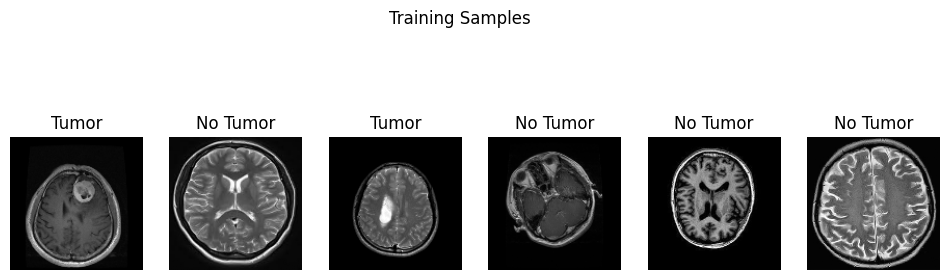

In [17]:
def show_samples(images, labels, title, n=6):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title("Tumor" if labels[i] == 1 else "No Tumor")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

# Show random samples
idx = np.random.randint(0, X_train.shape[0], 6)
show_samples(X_train[idx], y_train[idx], "Training Samples")

# CNN_Classifier

In [18]:
import json
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Input,
    SpatialDropout2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [19]:
def build_classifier(input_shape=(128, 128, 1)):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(256, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    # x = GlobalAveragePooling2D()(x)
    x = SpatialDropout2D(0.3)(x)
    x = GlobalAveragePooling2D()(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs, name="tumor_classifier")
    return model

In [20]:
classifier = build_classifier()

classifier.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

classifier.summary()

Model: "tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 16, 16, 256)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,017 (1.49 MB)

 Trainable params: 389,057 (1.48 MB)

 Non-trainable params: 960 (3.75 KB)

<span style= "color:Yellow">Model Train<span>

In [108]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop]
)

classifier.save("tumor_classifier_axial.h5")
print("✅ Classifier saved.")

with open("classifier_history.json", "w") as f:
    json.dump(history.history, f)

print("✅ Training history saved.")

Epoch 1/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 145s 481ms/step - accuracy: 0.7183 - loss: 0.5504 - val_accuracy: 0.4835 - val_loss: 0.8929
Epoch 2/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 132s 454ms/step - accuracy: 0.7982 - loss: 0.4404 - val_accuracy: 0.7013 - val_loss: 0.5760
Epoch 3/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 131s 451ms/step - accuracy: 0.8304 - loss: 0.3897 - val_accuracy: 0.8274 - val_loss: 0.4097
Epoch 4/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 130s 449ms/step - accuracy: 0.8579 - loss: 0.3366 - val_accuracy: 0.8898 - val_loss: 0.2896
Epoch 5/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 136s 470ms/step - accuracy: 0.8825 - loss: 0.2931 - val_accuracy: 0.9266 - val_loss: 0.2537
Epoch 6/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 176s 607ms/step - accuracy: 0.8959 - loss: 0.2644 - val_accuracy: 0.8862 - val_loss: 0.3147
Epoch 7/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 167s 574ms/step - accuracy: 0.9049 - loss: 0.2463 - val_accuracy: 0.8727 - val_loss: 0.2727
Epoch 8/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 224s 772ms/step - accuracy: 0.9194 -

✅ Classifier saved.
✅ Training history saved.


<span style="color:red">Load the model and the training history"<span>

In [21]:
classifier = load_model("tumor_classifier_axial.h5")
classifier.trainable = False

print("✅ Saved classifier loaded for evaluation.")

with open("classifier_history.json", "r") as f:
    saved_history = json.load(f)
    print("✅ Training history loaded.")


✅ Saved classifier loaded for evaluation.
✅ Training history loaded.


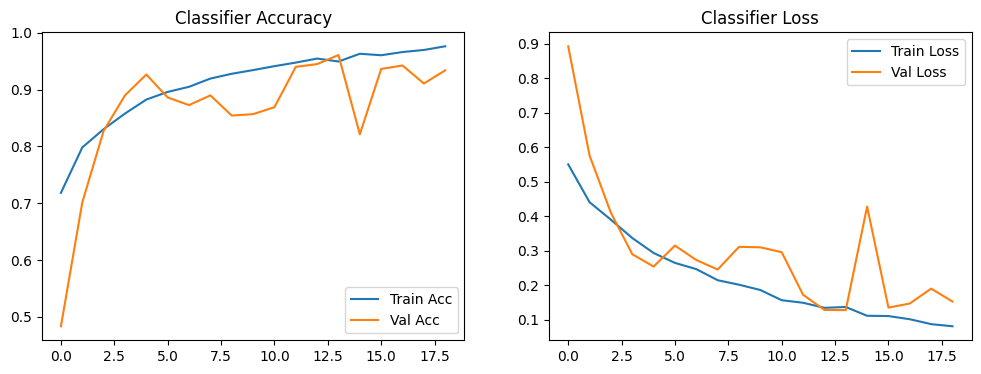

In [22]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(saved_history["accuracy"], label="Train Acc")
plt.plot(saved_history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Classifier Accuracy")

plt.subplot(1,2,2)
plt.plot(saved_history["loss"], label="Train Loss")
plt.plot(saved_history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Classifier Loss")

plt.show()

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step


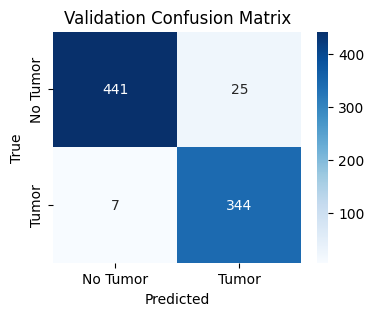

              precision    recall  f1-score   support

    No Tumor       0.98      0.95      0.96       466
       Tumor       0.93      0.98      0.96       351

    accuracy                           0.96       817
   macro avg       0.96      0.96      0.96       817
weighted avg       0.96      0.96      0.96       817



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_val_pred = (classifier.predict(X_val) > 0.5).astype(int)

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.show()

print(classification_report(y_val, y_val_pred, target_names=["No Tumor", "Tumor"]))

In [24]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

In [25]:
def grad_cam(model, img, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    # 🔥 Resize to original image size (fix pixelation)
    heatmap = tf.image.resize(
        heatmap[..., tf.newaxis],
        (IMG_SIZE, IMG_SIZE)
    )

    heatmap = tf.squeeze(heatmap)

    return heatmap.numpy()

In [26]:
def visualize_gradcam(model, image):

    layer_name = get_last_conv_layer(model)
    print("Using layer:", layer_name)

    # Ensure tensor for Grad-CAM
    image_tensor = tf.convert_to_tensor(image)

    heatmap = grad_cam(model, image_tensor, layer_name)

    # Handle numpy or tensor input safely
    if isinstance(image, np.ndarray):
        image_np = image[0].squeeze()
    else:
        image_np = image[0].numpy().squeeze()

    plt.figure(figsize=(8,4))

    # Original
    plt.subplot(1,2,1)
    plt.imshow(image_np, cmap="gray")
    plt.title("Original MRI")
    plt.axis("off")

    # Overlay
    plt.subplot(1,2,2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Using layer: conv2d_19


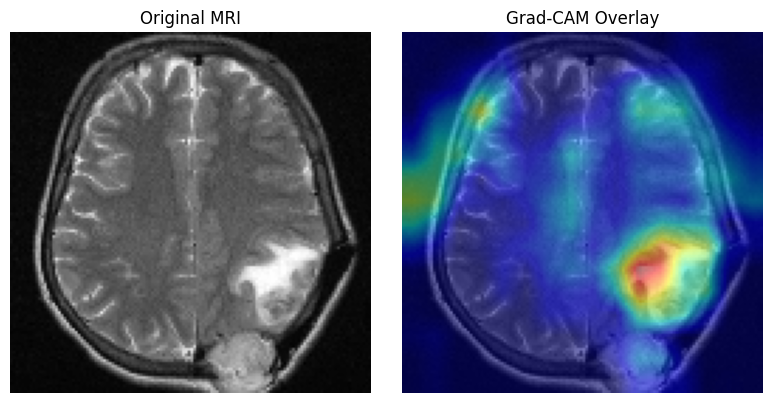

In [43]:
sample_idx = np.random.randint(0, X_val.shape[0])
sample_img = X_val[sample_idx:sample_idx+1]

visualize_gradcam(classifier, sample_img)

# GAN
Redesign the GAN latent space to separate anatomical structure from pathology and integrate a frozen classifier into the training loop, forcing the generator to encode disease-specific features in a controllable and interpretable manner.

GAN .h5

In [44]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Dense, Reshape, Flatten,
    Conv2D, Conv2DTranspose,
    LeakyReLU, BatchNormalization, Input
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam

In [45]:
LATENT_DIM = 100
STRUCTURE_DIM = 80
PATHOLOGY_DIM = 20

assert STRUCTURE_DIM + PATHOLOGY_DIM == LATENT_DIM

IMG_SIZE = 128
CHANNELS = 1

EPOCHS = 60
BATCH_SIZE = 16

CHECKPOINT_DIR = "gan_checkpoints_V2_h5"
IMAGE_DIR = "gan_generated_images_V2_h5"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

In [46]:
def build_generator():
    z = Input(shape=(LATENT_DIM,), name="latent_vector")

    x = Dense(32 * 32 * 256)(z)
    x = LeakyReLU(0.2)(x)
    x = Reshape((32, 32, 256))(x)

    x = Conv2DTranspose(128, 4, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(64, 4, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    out = Conv2D(1, 3, padding="same", activation="tanh")(x)

    return Model(z, out, name="Generator")

In [47]:
def build_discriminator():
    img = Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    x = Conv2D(64, 3, strides=2, padding="same")(img)
    x = LeakyReLU(0.2)(x)

    x = Conv2D(128, 3, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2D(256, 3, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Flatten()(x)
    out = Dense(1, activation="sigmoid")(x)

    return Model(img, out, name="Discriminator")

In [48]:
generator = build_generator()
discriminator = build_discriminator()

bce = tf.keras.losses.BinaryCrossentropy()

gen_optimizer = Adam(2e-4, beta_1=0.5)
disc_optimizer = Adam(2e-4, beta_1=0.5)

LAMBDA_CLS = 1.0

classifier = load_model("tumor_classifier_axial.h5")
classifier.trainable = False

In [49]:
def sample_latent(batch_size, labels):
    labels = tf.cast(labels, tf.float32)

    z_structure = tf.random.normal((batch_size, STRUCTURE_DIM))
    z_pathology_noise = tf.random.normal((batch_size, PATHOLOGY_DIM))

    z_pathology = z_pathology_noise * labels

    z = tf.concat([z_structure, z_pathology], axis=1)
    return z

In [50]:
@tf.function
def train_step(real_images, labels):

    batch_size = tf.shape(real_images)[0]
    labels = tf.cast(labels, tf.float32)

    z = sample_latent(batch_size, labels)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator(z, training=True)

        real_preds = discriminator(real_images, training=True)
        fake_preds = discriminator(fake_images, training=True)

        d_loss = (
            bce(tf.ones_like(real_preds), real_preds) +
            bce(tf.zeros_like(fake_preds), fake_preds)
        )

        cls_preds = classifier(fake_images, training=False)
        cls_loss = bce(labels, cls_preds)

        g_adv = bce(tf.ones_like(fake_preds), fake_preds)
        g_loss = g_adv + LAMBDA_CLS * cls_loss

    gen_grads = gen_tape.gradient(g_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return g_loss, d_loss

In [51]:
FIXED_BATCH = 6
fixed_labels = tf.ones((FIXED_BATCH,1))  # tumor samples
fixed_z = sample_latent(FIXED_BATCH, fixed_labels)

Epoch 1/60 | G: 5.7553 | D: 0.3713
Epoch 2/60 | G: 3.4724 | D: 0.4090
Epoch 3/60 | G: 4.0557 | D: 0.7562
Epoch 4/60 | G: 3.3033 | D: 0.1032
Epoch 5/60 | G: 1.0397 | D: 0.8208
Epoch 6/60 | G: 3.4645 | D: 0.7925
Epoch 7/60 | G: 4.5087 | D: 0.4590
Epoch 8/60 | G: 3.5098 | D: 0.1892
Epoch 9/60 | G: 2.7666 | D: 0.3455


Epoch 10/60 | G: 4.7062 | D: 0.3165


✅ Models saved


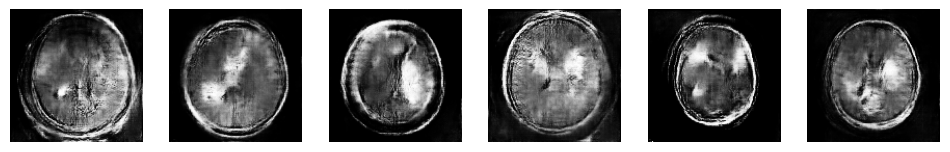

Epoch 11/60 | G: 1.1503 | D: 1.1013
Epoch 12/60 | G: 1.9947 | D: 1.2748
Epoch 13/60 | G: 1.3447 | D: 0.9207
Epoch 14/60 | G: 0.9276 | D: 1.0545
Epoch 15/60 | G: 2.7086 | D: 0.3485
Epoch 16/60 | G: 2.5338 | D: 0.2638
Epoch 17/60 | G: 6.3859 | D: 0.7794
Epoch 18/60 | G: 4.1794 | D: 0.4333
Epoch 19/60 | G: 5.5034 | D: 0.4253


Epoch 20/60 | G: 7.5751 | D: 1.0101


✅ Models saved


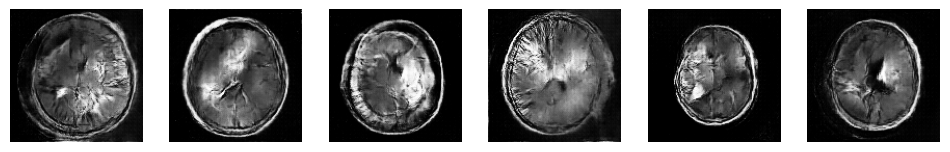

Epoch 21/60 | G: 0.7981 | D: 1.1030
Epoch 22/60 | G: 7.4186 | D: 0.0336
Epoch 23/60 | G: 0.8363 | D: 1.4039
Epoch 24/60 | G: 3.0408 | D: 0.1993
Epoch 25/60 | G: 5.6423 | D: 0.0648
Epoch 26/60 | G: 5.5673 | D: 2.4757
Epoch 27/60 | G: 1.3147 | D: 0.6808
Epoch 28/60 | G: 7.9612 | D: 1.4374
Epoch 29/60 | G: 4.4715 | D: 0.7679


Epoch 30/60 | G: 3.5928 | D: 0.9887


✅ Models saved


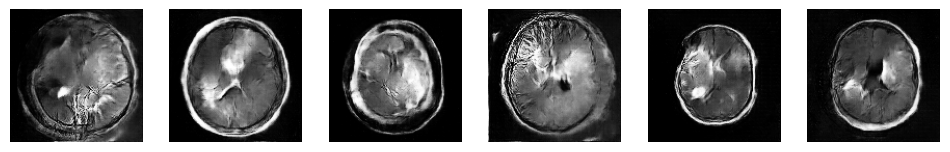

Epoch 31/60 | G: 6.2941 | D: 0.2728
Epoch 32/60 | G: 3.9535 | D: 1.4001
Epoch 33/60 | G: 1.4368 | D: 0.7175
Epoch 34/60 | G: 3.1861 | D: 0.0667
Epoch 35/60 | G: 2.6032 | D: 0.2367
Epoch 36/60 | G: 1.8881 | D: 0.3276
Epoch 37/60 | G: 4.0975 | D: 0.0984
Epoch 38/60 | G: 4.0975 | D: 1.2214
Epoch 39/60 | G: 3.9497 | D: 0.1386


Epoch 40/60 | G: 3.7144 | D: 0.1997


✅ Models saved


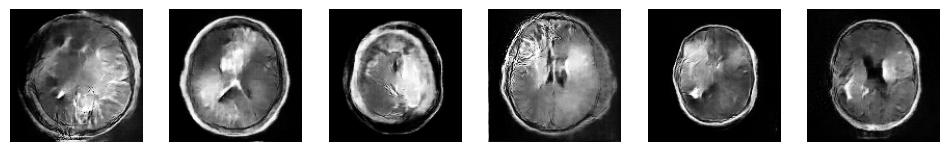

Epoch 41/60 | G: 3.8000 | D: 0.0831
Epoch 42/60 | G: 2.3428 | D: 0.3888
Epoch 43/60 | G: 5.3769 | D: 1.0331
Epoch 44/60 | G: 2.3372 | D: 0.4821
Epoch 45/60 | G: 6.3026 | D: 0.3898
Epoch 46/60 | G: 7.5287 | D: 1.0067
Epoch 47/60 | G: 3.4035 | D: 0.5320
Epoch 48/60 | G: 3.6510 | D: 1.3681
Epoch 49/60 | G: 5.5035 | D: 0.4606


Epoch 50/60 | G: 5.2752 | D: 1.1630


✅ Models saved


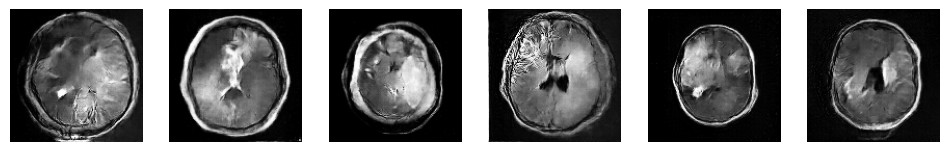

Epoch 51/60 | G: 3.1401 | D: 0.1671
Epoch 52/60 | G: 6.9775 | D: 1.2583
Epoch 53/60 | G: 5.4041 | D: 0.3872
Epoch 54/60 | G: 3.3489 | D: 0.1083
Epoch 55/60 | G: 5.6442 | D: 0.0100
Epoch 56/60 | G: 2.0699 | D: 0.4374
Epoch 57/60 | G: 2.4883 | D: 0.4460
Epoch 58/60 | G: 2.6622 | D: 0.4184
Epoch 59/60 | G: 3.2959 | D: 0.2915


Epoch 60/60 | G: 3.3853 | D: 0.2954


✅ Models saved


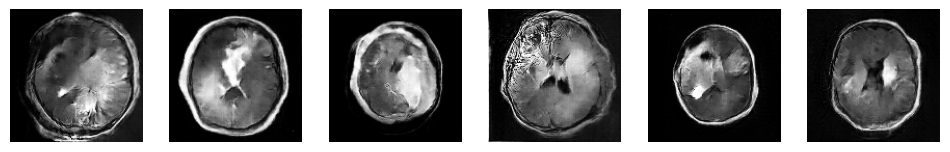

In [41]:
for epoch in range(EPOCHS):

    idx = np.random.permutation(len(X_train))

    for i in range(0, len(X_train), BATCH_SIZE):
        batch_idx = idx[i:i+BATCH_SIZE]

        real_imgs = X_train[batch_idx]
        labels = y_train[batch_idx].reshape(-1,1)

        g_loss, d_loss = train_step(real_imgs, labels)

    print(f"Epoch {epoch+1}/{EPOCHS} | G: {g_loss:.4f} | D: {d_loss:.4f}")

    if (epoch+1) % 10 == 0:

        # Save generator & discriminator
        generator.save(
            os.path.join(CHECKPOINT_DIR, f"generator_epoch_{epoch+1}.h5")
        )

        discriminator.save(
            os.path.join(CHECKPOINT_DIR, f"discriminator_epoch_{epoch+1}.h5")
        )

        print("✅ Models saved")

        # Generate images
        generated = generator(fixed_z, training=False)
        generated = (generated + 1) / 2.0

        plt.figure(figsize=(12,4))
        for i in range(FIXED_BATCH):
            plt.subplot(1,FIXED_BATCH,i+1)
            plt.imshow(generated[i].numpy().squeeze(), cmap="gray")
            plt.axis("off")

            plt.imsave(
                os.path.join(
                    IMAGE_DIR,
                    f"epoch_{epoch+1}_img_{i}.png"
                ),
                generated[i].numpy().squeeze(),
                cmap="gray"
            )

        plt.show()

In [52]:
generator = load_model("gan_checkpoints_V2_h5/generator_epoch_60.h5")
classifier = load_model("tumor_classifier_axial.h5")
classifier.trainable = False

In [1]:
def generate_counterfactual(generator):

    z_structure = tf.random.normal((1, STRUCTURE_DIM))

    z_no = tf.concat(
        [z_structure, tf.zeros((1, PATHOLOGY_DIM))],
        axis=1
    )

    z_yes = tf.concat(
        [z_structure, tf.random.normal((1, PATHOLOGY_DIM))],
        axis=1
    )

    img_no = generator(z_no, training=False)
    img_yes = generator(z_yes, training=False)

    return img_no, img_yes

In [54]:
def visualize_counterfactual(img_no, img_yes):

    img_no = (img_no + 1)/2.0
    img_yes = (img_yes + 1)/2.0

    diff = tf.abs(img_yes - img_no)
    diff /= tf.reduce_max(diff) + 1e-8

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_no[0].numpy().squeeze(), cmap="gray")
    plt.title("No Tumor")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img_yes[0].numpy().squeeze(), cmap="gray")
    plt.title("Tumor")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(diff[0].numpy().squeeze(), cmap="hot")
    plt.title("Difference Map")
    plt.axis("off")

    plt.show()

    print("Classifier No Tumor:",
          classifier(img_no).numpy()[0][0])

    print("Classifier Tumor:",
          classifier(img_yes).numpy()[0][0])

# EXPLAINABILITY MODULE

# Counterfactual

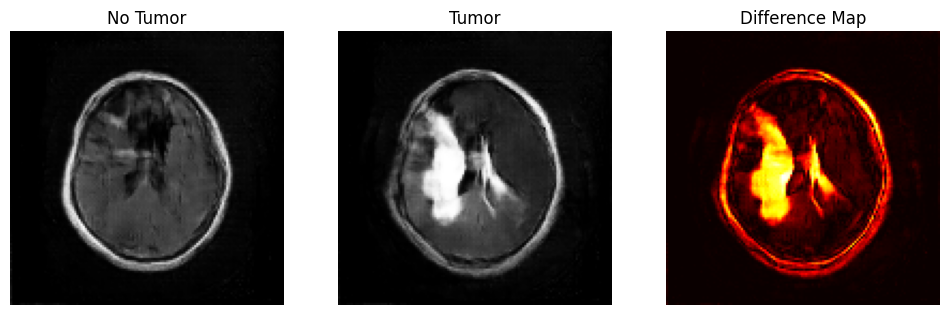

Classifier No Tumor: 0.99055314
Classifier Tumor: 0.99419385


In [115]:
img_no, img_yes = generate_counterfactual(generator)
visualize_counterfactual(img_no, img_yes)

## Generate Images from Checkpoints




In [116]:
discriminator = load_model("gan_checkpoints_V2_h5/discriminator_epoch_60.h5")
discriminator.trainable = False

print("✅ Discriminator loaded")

✅ Discriminator loaded


In [117]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")

In [118]:
def gradcam_discriminator(model, image):

    layer_name = get_last_conv_layer(model)
    print("Using layer:", layer_name)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    image = tf.convert_to_tensor(image)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, 0]   # realism score

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    # 🔥 Resize to match image
    heatmap = tf.image.resize(
        heatmap[..., tf.newaxis],
        (128, 128)
    )

    heatmap = tf.squeeze(heatmap)

    return heatmap.numpy()

In [119]:
def visualize_discriminator_attention(model, image):

    heatmap = gradcam_discriminator(model, image)

    if isinstance(image, np.ndarray):
        img_np = image[0].squeeze()
    else:
        img_np = image[0].numpy().squeeze()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img_np, cmap="gray")
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img_np, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.title("Discriminator Attention")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Using layer: conv2d_19


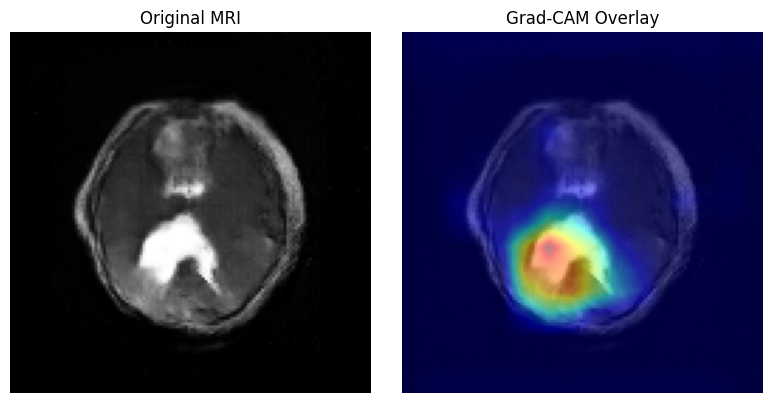

Classifier confidence after masking explanation: 0.876


In [156]:
img_no, img_yes = generate_counterfactual(generator)
visualize_gradcam(classifier, img_yes)

# compute difference map
diff = tf.abs(img_yes - img_no)
diff = tf.clip_by_value(diff, 0, 1)
diff /= tf.reduce_max(diff) + 1e-8

# tumor image
img_tumor = img_yes

# mask explanation region
masked_img = img_tumor * (1 - diff)

# classifier prediction
p_masked = classifier(masked_img, training=False).numpy()[0][0]

print(f"Classifier confidence after masking explanation: {p_masked:.3f}")

In [161]:
from skimage.metrics import structural_similarity as ssim

real_img = X_train[np.random.randint(0, X_train.shape[0])].squeeze()
gen_img = img_tumor[0].numpy().squeeze()

score = ssim(real_img, gen_img, data_range=2)
print("SSIM score:", score)

SSIM score: 0.48883654172787444


✅ Generator loaded


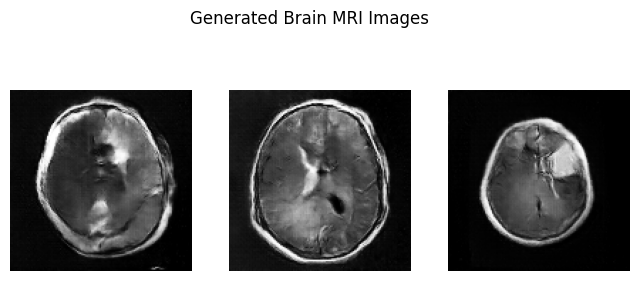

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

LATENT_DIM = 100
STRUCTURE_DIM = 80
PATHOLOGY_DIM = 20
NUM_IMAGES = 3   # number of MRIs to generate

generator = load_model("gan_checkpoints_V2_h5/generator_epoch_60.h5")
print("✅ Generator loaded")

z_structure = tf.random.normal((NUM_IMAGES, STRUCTURE_DIM))
z_pathology = tf.random.normal((NUM_IMAGES, PATHOLOGY_DIM))

z = tf.concat([z_structure, z_pathology], axis=1)

generated_images = generator(z, training=False)

generated_images = (generated_images + 1) / 2.0

plt.figure(figsize=(8,8))

for i in range(NUM_IMAGES):
    plt.subplot(3,3,i+1)
    plt.imshow(generated_images[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Brain MRI Images")
plt.show()

✅ Generator loaded


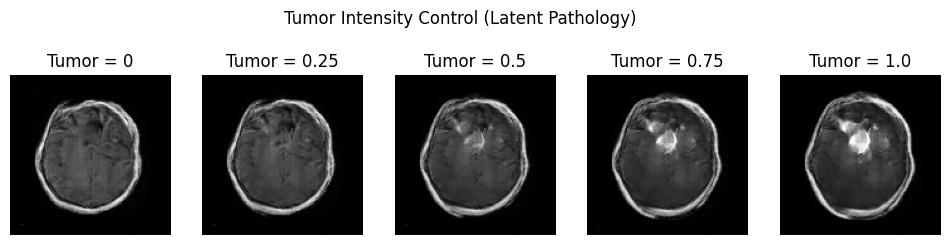

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


STRUCTURE_DIM = 80
PATHOLOGY_DIM = 20
LATENT_DIM = 100

generator = load_model("gan_checkpoints_V2_h5/generator_epoch_60.h5")
print("✅ Generator loaded")


z_structure = tf.random.normal((1, STRUCTURE_DIM))

z_pathology_base = tf.random.normal((1, PATHOLOGY_DIM))

tumor_levels = [0, 0.25, 0.5, 0.75, 1.0]

generated_images = []

for level in tumor_levels:

    z_pathology = level * z_pathology_base

    z = tf.concat([z_structure, z_pathology], axis=1)

    img = generator(z, training=False)

    img = (img + 1) / 2.0

    generated_images.append(img)

plt.figure(figsize=(12,3))

for i, level in enumerate(tumor_levels):

    plt.subplot(1, len(tumor_levels), i+1)

    plt.imshow(generated_images[i][0].numpy().squeeze(), cmap="gray")

    plt.title(f"Tumor = {level}")

    plt.axis("off")

plt.suptitle("Tumor Intensity Control (Latent Pathology)")
plt.show()